# SI — Raw EIS Figures

**Wavelength-Resolved Photo-Impedance and Leakage-Aware Machine Learning Reveal a
Schottky-to-Plasmonic Mechanism Transition in Ag/Au/g-C3N4 Photocathodes for
Hydrogen Evolution**

This notebook reads the raw Gamry `.DTA` EIS files directly, rather than the
processed master table used elsewhere in this project, because the frequency-sweep
Nyquist shape is not preserved in the derived descriptors (`Rs_ohm`, `Rct_ohm`,
`tau_s`, etc.) used in Notebooks 02-05. It produces the dark-state Nyquist
comparison across all seven catalysts.

**Input:** raw `.DTA` files under `Dataset/EIS_AgAu/`.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from utils import SAMPLE_ORDER, SAMPLE_COLORS

def load_dta(filepath):
    """
    Parse a Gamry .DTA EIS file into a DataFrame with columns:
    Freq, Zreal, Zimag, Zmod, Zphz.

    Locates the ZCURVE data table and reads tab-separated values,
    skipping the two header rows that follow the ZCURVE marker.
    """
    with open(filepath, encoding='latin1') as f:
        lines = f.readlines()

    start = None
    for i, line in enumerate(lines):
        if line.strip().startswith('ZCURVE'):
            start = i + 3  # data starts 3 lines after the ZCURVE marker
            break
    if start is None:
        raise ValueError(f"No ZCURVE section found in {filepath}")

    rows = []
    for line in lines[start:]:
        parts = line.strip().split('\t')
        if len(parts) < 8:
            continue
        try:
            freq  = float(parts[2])
            zreal = float(parts[3])
            zimag = float(parts[4])
            zmod  = float(parts[6])
            zphz  = float(parts[7])
        except ValueError:
            continue
        rows.append({"Freq": freq, "Zreal": zreal, "Zimag": zimag,
                      "Zmod": zmod, "Zphz": zphz})

    return pd.DataFrame(rows)

print("load_dta() ready")

load_dta() ready


The parser reads Gamry's native `.DTA` export format directly, locating the
`ZCURVE` data block and skipping its two header rows.

## 1. Confirm Raw Data Folders Are Reachable

In [2]:
AG_DIR   = "Dataset/EIS_AgAu/Ag/"
AU_DIR   = "Dataset/EIS_AgAu/Au/"
C3N4_DIR = "Dataset/EIS_AgAu/Au/"  # C3N4 files are stored alongside the Au series

for label, d in [("Ag", AG_DIR), ("Au", AU_DIR)]:
    exists = os.path.isdir(d)
    n_files = len([f for f in os.listdir(d) if f.endswith(".DTA")]) if exists else 0
    print(f"{label} dir: {d}  |  exists={exists}  |  .DTA files found={n_files}")

Ag dir: Dataset/EIS_AgAu/Ag/  |  exists=True  |  .DTA files found=36
Au dir: Dataset/EIS_AgAu/Au/  |  exists=True  |  .DTA files found=48


## 2. Dark Nyquist Plot — All Seven Catalysts

Compares the dark-state impedance spectra at −0.6 V vs RHE across the full
catalyst set. The raw Gamry files label voltage on the Ag/AgCl scale; −0.6 V
vs RHE corresponds to the "-1,6V" file tag via the same reference-electrode
offset (+0.971 V) used to convert every voltage reported in this project.

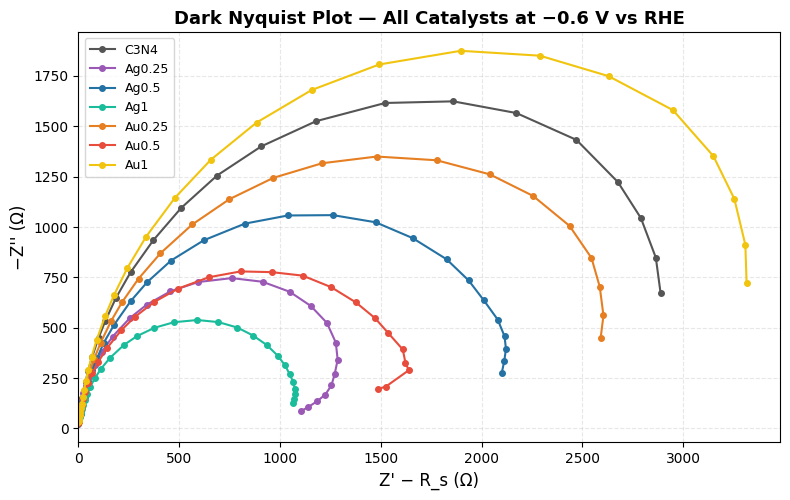

Saved: Results/figure_dark_nyquist_all.png


In [3]:
VOLT = "-1,6V"

sample_dirs = {
    "C3N4":   C3N4_DIR, "Ag0.25": AG_DIR, "Ag0.5": AG_DIR, "Ag1": AG_DIR,
    "Au0.25": AU_DIR, "Au0.5": AU_DIR, "Au1": AU_DIR,
}

fig, ax = plt.subplots(figsize=(8, 7))

for sample in SAMPLE_ORDER:
    d = sample_dirs[sample]
    dark_files = [f for f in os.listdir(d)
                  if sample in f and "dark" in f.lower()
                  and "dark2" not in f and VOLT in f]
    if not dark_files:
        print(f"WARNING: no dark file found for {sample} at {VOLT}")
        continue

    df = load_dta(d + dark_files[0])
    if df.empty:
        print(f"WARNING: {dark_files[0]} parsed to zero rows")
        continue

    Rs = df["Zreal"].min()
    ax.plot(df["Zreal"] - Rs, -df["Zimag"], "o-",
            color=SAMPLE_COLORS[sample], linewidth=1.5, markersize=4,
            label=sample)

ax.set_xlabel("Z' − R_s (Ω)", fontsize=12)
ax.set_ylabel("−Z'' (Ω)", fontsize=12)
ax.set_title("Dark Nyquist Plot — All Catalysts at −0.6 V vs RHE",
             fontweight="bold", fontsize=13)
ax.set_xlim(left=0)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig("Results/figure_dark_nyquist_all.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: Results/figure_dark_nyquist_all.png")

R_ct is largest (widest semicircle) for 1.0% Au/g-C3N4 and for bare g-C3N4,
consistent with the higher interfacial resistance of both the metal-free
surface and the aggregated high-loading Au surface. This figure is the raw
EIS counterpart to the derived-descriptor comparisons in Notebook 02.